# Design & Build a RAG-Based Customer Support Assistant (with LangGraph & HITL)

In [ ]:
!pip install langchain langchain-community langchain-groq
!pip install chromadb sentence-transformers
!pip install langgraph pypdf

In [ ]:
import os
os.environ["GROQ_API_KEY"] = "your_groq_api_key"

In [ ]:
key = os.environ.get("GROQ_API_KEY")
print("key loaded:", "yes" if key else "nope")

In [ ]:
# upload pdf and load it
from google.colab import files
from langchain_community.document_loaders import PyPDFLoader

up = files.upload()
fname = list(up.keys())[0]
print("uploaded:", fname)

loader = PyPDFLoader(fname)
raw = loader.load()
print(f"total pages loaded: {len(raw)}")

In [ ]:
!pip install langchain-text-splitters

In [ ]:
# split the doc into smaller pieces (chunks)
from langchain_text_splitters import RecursiveCharacterTextSplitter

spl = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = spl.split_documents(raw)

print(f"total chunks made: {len(chunks)}")
print("\n--- sample chunk ---")
print(chunks[0].page_content[:300])

In [ ]:
# embed chunks (vector store)
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings

# embedding model
emb = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

db = Chroma.from_documents(chunks, emb, collection_name="support_bot")
print(f"stored {len(chunks)} chunks in chromadb")

ret = db.as_retriever(search_kwargs={"k": 3})
test = ret.invoke("what is this document about")
print(f"\ntest retrieval returned {len(test)} chunks")

In [ ]:
# set up llm and connect to groq llm
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.3,
    groq_api_key=os.environ["GROQ_API_KEY"]
)

resp = llm.invoke("say hello in one line")
print("llm works:", resp.content)

In [ ]:
# Build the LangGraph workflow with HITL
from langgraph.graph import StateGraph, END
from typing import TypedDict, Optional

class State(TypedDict):
    q: str           # user question
    ctx: str         # retrieved context
    ans: str         # final answer
    route: str       # "answer" or "escalate"
    conf: float      # confidence score (0 to 1)

# ---- node 1: retrieve and check confidence ----
def process_node(s: State) -> State:
    q = s["q"]

    # get relevant chunks
    docs = ret.invoke(q)
    ctx = "\n".join([d.page_content for d in docs])

    # simple confidence check - based on how much context we found
    conf = min(len(ctx) / 800, 1.0)

    # decide route
    route = "escalate" if conf < 0.3 else "answer"

    print(f"[process] confidence: {conf:.2f} | route: {route}")
    return {**s, "ctx": ctx, "conf": conf, "route": route}

# ---- node 2a: generate answer ----
def answer_node(s: State) -> State:
    prompt = f"""You are a helpful customer support assistant.
Use the context below to answer the user's question.
If the context doesn't help, say you don't have enough info.

Context:
{s['ctx']}

Question: {s['q']}

Answer:"""

    out = llm.invoke(prompt)
    ans = out.content
    print(f"[answer] generated response")
    return {**s, "ans": ans}

# ---- node 2b: HITL escalation ----
def hitl_node(s: State) -> State:
    print(f"\n[HITL] low confidence ({s['conf']:.2f}) - escalating to human")
    print(f"[HITL] question: {s['q']}")

    # in real system this sends email/ticket - here we simulate
    human_input = input("[HITL] Type your human response (or press enter to auto-reply): ")

    if not human_input.strip():
        human_input = "Thank you for your question. A support agent will reach out within 24 hours."

    ans = f"[Escalated to human support]\n{human_input}"
    return {**s, "ans": ans}

# ---- routing function ----
def router(s: State) -> str:
    return s["route"]

# ---- build the graph ----
g = StateGraph(State)

g.add_node("process", process_node)
g.add_node("answer", answer_node)
g.add_node("hitl", hitl_node)

g.set_entry_point("process")

# conditional routing
g.add_conditional_edges(
    "process",
    router,
    {
        "answer": "answer",
        "escalate": "hitl"
    }
)

g.add_edge("answer", END)
g.add_edge("hitl", END)

bot = g.compile()
print("graph compiled successfully!")

In [ ]:
# run the support bot
def ask(question):
    print(f"\n{'='*50}")
    print(f"Question: {question}")
    print('='*50)

    init = {
        "q": question,
        "ctx": "",
        "ans": "",
        "route": "",
        "conf": 0.0
    }

    result = bot.invoke(init)

    print(f"\nFinal Answer:\n{result['ans']}")
    print(f"\n[confidence was: {result['conf']:.2f}]")
    return result

r1 = ask("What is this document about?")

In [ ]:
print("RAG Support Bot - type 'quit' to exit\n")

while True:
    user_q = input("You: ").strip()

    if user_q.lower() in ["quit", "exit", "q"]:
        print("Bye!")
        break

    if not user_q:
        continue

    ask(user_q)

In [ ]:
test_qs = [
    "What are the main topics covered?",
    "How do I contact support?",
    "xyz blah 123 random gibberish",
]

for q in test_qs:
    r = ask(q)
    print()

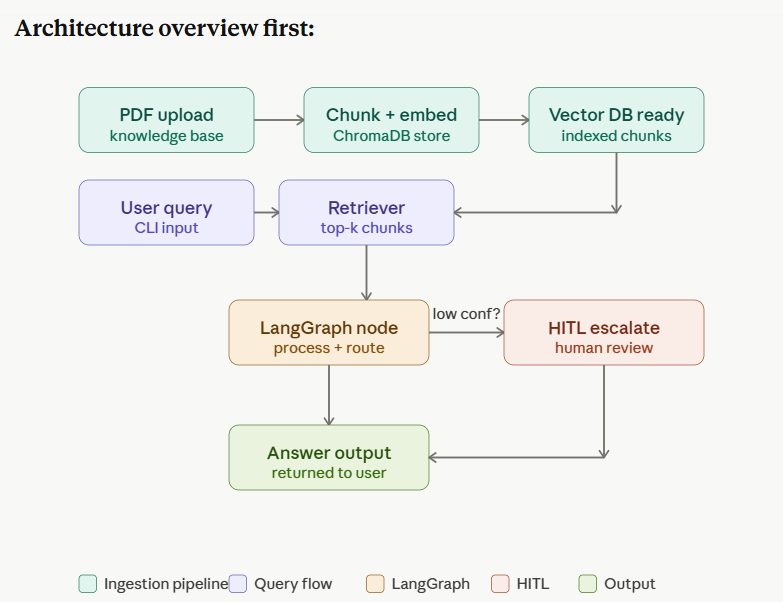